## Discalimer

NOTE: This notebook provides an explanation of the process only.

If you want to run the experiments and reproduce the results, please use `classes/main.py` or `classes/ablation.py`.

In [126]:
import pandas as pd
import numpy as np
from sklearn.metrics import accuracy_score, f1_score, log_loss, confusion_matrix, mean_absolute_error, mean_squared_error, r2_score
from sklearn.ensemble import GradientBoostingClassifier, GradientBoostingRegressor
import seaborn as sns
import matplotlib.pyplot as plt

Original dataset: https://archive.ics.uci.edu/dataset/502/online+retail+ii

In [151]:
BENCHMARK = False 

In [127]:
# PATH = ""
# DATASET = "online_retail_II_states_1M.csv" # Example dataset

# df_retail = pd.read_csv(f"{PATH}/{DATASET}")

In [128]:
df = df_retail

In [129]:
# Manage NaN (last row for each user), suppose next state is equal to t0
df['engagement_t1'] = df['engagement_t1'].fillna(df['engagement_t0'])

# Encode states as integers for sklearn
state_mapping = {'active': 0, 'dormant': 1, 'inactive': 2}
df['engagement_t0_code'] = df['engagement_t0'].map(state_mapping)
df['engagement_t1_code'] = df['engagement_t1'].map(state_mapping)

print(df.isna().sum())
df['avg_revenue_3m'] = df['avg_revenue_3m'].fillna(0)
df['activity_freq_3m'] = df['activity_freq_3m'].fillna(0)
df['revenue_volatility_3m'] = df['revenue_volatility_3m'].fillna(0)

# df = df.fillna(0)

df

CustomerID                   0
year_month                   0
Revenue                      0
Quantity                     0
Country                      0
avg_unit_price               0
num_invoices                 0
avg_rev_per_invoice          0
quantity_per_invoice         0
first_purchase_month         0
last_purchase_month      48419
year_month_ts                0
avg_revenue_3m               1
activity_freq_3m             1
revenue_volatility_3m        2
engagement_t0                0
engagement_t1                0
engagement_t0_code           0
engagement_t1_code           0
dtype: int64


,CustomerID,year_month,Revenue,Quantity,Country,avg_unit_price,num_invoices,avg_rev_per_invoice,quantity_per_invoice,first_purchase_month,last_purchase_month,year_month_ts,avg_revenue_3m,activity_freq_3m,revenue_volatility_3m,engagement_t0,engagement_t1,engagement_t0_code,engagement_t1_code
0,12346.0,2009-12,0.00,0.0,United Kingdom,0.000000,0.0,0.00,0.0,2010-03-01,NaN,2009-12-01,0.000000,0.0,0.000000,dormant,dormant,1,1
1,12346.0,2010-01,0.00,0.0,United Kingdom,0.000000,0.0,0.00,0.0,2010-03-01,NaN,2010-01-01,0.000000,0.0,0.000000,dormant,dormant,1,1
2,12346.0,2010-02,0.00,0.0,United Kingdom,0.000000,0.0,0.00,0.0,2010-03-01,NaN,2010-02-01,0.000000,0.0,0.000000,dormant,active,1,0
3,12346.0,2010-03,27.05,5.0,United Kingdom,5.410000,1.0,27.05,5.0,2010-03-01,2010-03-01,2010-03-01,0.000000,0.0,0.000000,active,inactive,0,2
4,12346.0,2010-04,0.00,0.0,United Kingdom,0.000000,0.0,0.00,0.0,2010-03-01,2010-03-01,2010-04-01,9.016667,1.0,15.617325,inactive,inactive,2,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
146970,18287.0,2011-08,0.00,0.0,United Kingdom,0.000000,0.0,0.00,0.0,2010-05-01,2011-05-01,2011-08-01,255.093333,1.0,441.834614,inactive,inactive,2,2
146971,18287.0,2011-09,0.00,0.0,United Kingdom,0.000000,0.0,0.00,0.0,2010-05-01,2011-05-01,2011-09-01,0.000000,0.0,0.000000,inactive,active,2,0
146972,18287.0,2011-10,1072.00,1098.0,United Kingdom,0.976321,2.0,536.00,549.0,2010-05-01,2011-10-01,2011-10-01,0.000000,0.0,0.000000,active,inactive,0,2
146973,18287.0,2011-11,0.00,0.0,United Kingdom,0.000000,0.0,0.00,0.0,2010-05-01,2011-10-01,2011-11-01,357.333333,1.0,618.919489,inactive,inactive,2,2


# Step 3: Engagement State Transition Modeling

In [130]:
train_ratio = 0.8
test_ratio = 0.2

train_list = []
test_list = []

for customer_id, group in df.groupby('CustomerID'):
    n = len(group)
    train_end = int(n * train_ratio)
    
    train = group.iloc[:train_end]
    test = group.iloc[train_end:]
    
    train_list.append(train)
    test_list.append(test)

train_df = pd.concat(train_list)
test_df = pd.concat(test_list)

In [131]:
# Check samples per user in splits
print(df[df['CustomerID'] == 18287.0].shape)
print(train_df[train_df['CustomerID'] == 18287.0].shape)
print(test_df[test_df['CustomerID'] == 18287.0].shape)

assert (train_df[train_df['CustomerID'] == 18287.0].shape[0] + test_df[test_df['CustomerID'] == 18287.0].shape[0]) == (df[df['CustomerID'] == 18287.0].shape[0])

(25, 19)
(20, 19)
(5, 19)


Markov transition model is used as a baseline.

In [132]:
# Build transition counts
transition_counts = pd.crosstab(train_df['engagement_t0'], train_df['engagement_t1'])

# Convert to probabilities (transition matrix)
transition_matrix = transition_counts.div(transition_counts.sum(axis=1), axis=0)

# transition matrix computed on all customers on all months => I can use this to predict future horizons
transition_matrix

engagement_t1,active,dormant,inactive
engagement_t0,,,
active,0.378044,0.000000,0.621956
dormant,0.087217,0.912783,0.000000
inactive,0.164843,0.017412,0.817745


The other model is a GradientBoostClassifier

In [133]:
def forecast_next_state_with_model(
    current_state,
    features,
    transition_matrix,
    clf,
    state_mapping={'active': 0, 'dormant': 1, 'inactive': 2},
    lambda_weight=0.5
):
    base_probs = transition_matrix.loc[current_state].values
    state_code = state_mapping[current_state]

    input_dict = {'engagement_t0_code': [state_code]}

    for i, col in enumerate(feature_cols):
        input_dict[col] = [features[i]]
        
    X_feat = pd.DataFrame(input_dict)
    feat_probs = clf.predict_proba(X_feat)[0]
    # final_probs = (1 - lambda_weight) * base_probs + lambda_weight * feat_probs
    final_probs = feat_probs
    return final_probs

def row_forecast(row):
    current_state = row['engagement_t0']
    features = [row[col] for col in feature_cols]
    probs = forecast_next_state_with_model(current_state, features, transition_matrix, clf)
    pred_code = np.argmax(probs)  # predicted state code
    return pred_code, probs

In [134]:
# Ensure both columns are datetime
train_df['year_month_ts'] = pd.to_datetime(train_df['year_month_ts'])
train_df['last_purchase_month'] = pd.to_datetime(train_df['last_purchase_month'])
test_df['year_month_ts'] = pd.to_datetime(test_df['year_month_ts'])
test_df['last_purchase_month'] = pd.to_datetime(test_df['last_purchase_month'])

# Calculate months since last purchase
def months_diff(row):
    if pd.isnull(row['last_purchase_month']):
        return -1
    diff = (row['year_month_ts'].year - row['last_purchase_month'].year) * 12 + \
           (row['year_month_ts'].month - row['last_purchase_month'].month)
    return int(diff)

train_df['months_since_last_purchase'] = train_df.apply(months_diff, axis=1)
test_df['months_since_last_purchase'] = test_df.apply(months_diff, axis=1)

# et NaNs to -1 to indicate “no purchase yet.”
# train_df['months_since_last_purchase'] = train_df['last_purchase_month'].fillna(-1)
# test_df['months_since_last_purchase'] = test_df['last_purchase_month'].fillna(-1)

In [135]:
train_df.dtypes

CustomerID                           float64
year_month                               str
Revenue                              float64
Quantity                             float64
Country                                  str
avg_unit_price                       float64
num_invoices                         float64
avg_rev_per_invoice                  float64
quantity_per_invoice                 float64
first_purchase_month                     str
last_purchase_month           datetime64[us]
year_month_ts                 datetime64[us]
avg_revenue_3m                       float64
activity_freq_3m                     float64
revenue_volatility_3m                float64
engagement_t0                            str
engagement_t1                            str
engagement_t0_code                     int64
engagement_t1_code                     int64
months_since_last_purchase             int64
dtype: object

In [136]:
train_df['months_since_last_purchase']

0        -1
1        -1
2        -1
3         0
4         1
         ..
146965    4
146966    5
146967    0
146968    1
146969    2
Name: months_since_last_purchase, Length: 117580, dtype: int64

In [137]:
# Features to use
feature_cols = ['avg_unit_price', 'num_invoices', 'avg_rev_per_invoice',
                'quantity_per_invoice', 'avg_revenue_3m', 'activity_freq_3m',
                'revenue_volatility_3m', 'months_since_last_purchase']

# Train a classifier to predict next state, given current state and features
X = train_df[['engagement_t0_code'] + feature_cols]
y = train_df['engagement_t1_code']
clf = GradientBoostingClassifier()
clf.fit(X, y)

# Apply to each row in test_df
results = test_df.apply(row_forecast, axis=1)
test_df['model_predicted_code_T1'] = [r[0] for r in results]
test_df['model_predicted_probs_T1'] = [r[1] for r in results]

y_true = test_df['engagement_t1_code']
y_pred = test_df['model_predicted_code_T1']

accuracy = accuracy_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred, average='weighted')
cm = confusion_matrix(y_true, y_pred)

print("Accuracy:", round(accuracy, 2))
print("F1-score:", round(f1, 2))
print("Confusion matrix:\n", cm)

Accuracy: 0.83
F1-score: 0.79
Confusion matrix:
 [[ 1274   805  3446]
 [    0  6899     0]
 [  673   119 16179]]


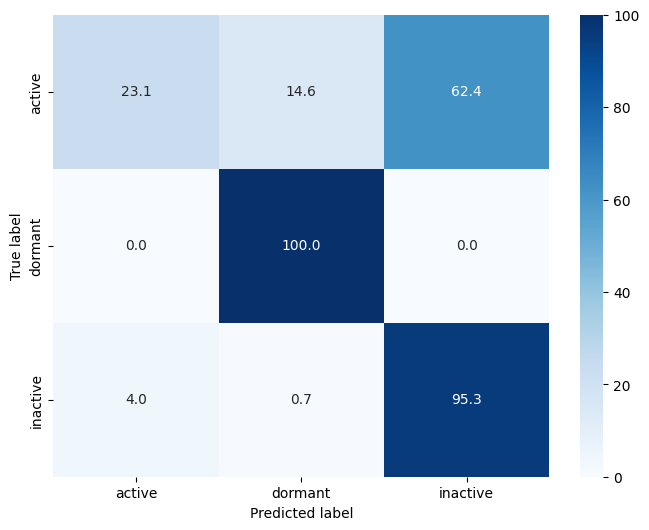

In [138]:
state_mapping = {'active': 0, 'dormant': 1, 'inactive': 2}
# Sort by value to get the correct order
labels = [k for k, v in sorted(state_mapping.items(), key=lambda item: item[1])]

# Normalize by row (axis=1)
cm_percent = cm / cm.sum(axis=1, keepdims=True) * 100

plt.figure(figsize=(8,6))
sns.heatmap(
    cm_percent,
    annot=True,
    fmt=".1f",
    cmap="Blues",
    xticklabels=labels,
    yticklabels=labels
)
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.show()

## Benchmarks

We are going to evaluate the results of GBC vs. the predictions made with Markov Transition matrix and also vs:
- naive repetition (next state = actual state)
- global and entity level mean predictors

### Markov transition model
A naive Markov transition model without features is used as a baseline

In [139]:
# For each test row
def naive_markov_predict(current_state, transition_matrix):
    # Get the transition probabilities for the current state
    return transition_matrix.loc[current_state].values

# Predict for all test rows
test_df['markov_probs_T1'] = test_df['engagement_t0'].apply(lambda s: naive_markov_predict(s, transition_matrix))
test_df['markov_pred_code_T1'] = test_df['markov_probs_T1'].apply(np.argmax)

# Naive Markov
y_pred_naive = test_df['markov_pred_code_T1']
accuracy_naive = accuracy_score(y_true, y_pred_naive)
f1_naive = f1_score(y_true, y_pred_naive, average='weighted')
ll_naive = log_loss(y_true, np.stack(test_df['markov_probs_T1'].values))

# Gradient Boost Classifier
y_pred_model = test_df['model_predicted_code_T1']
accuracy_model = accuracy_score(y_true, y_pred_model)
f1_model = f1_score(y_true, y_pred_model, average='weighted')
ll_model = log_loss(y_true, np.stack(test_df['model_predicted_probs_T1'].values))

### Naive persistence

In [141]:
if BENCHMARK:
    # The naive prediction is just the current state
    train_df['naive_pred'] = train_df['engagement_t0']

    # Drop rows where engagement_t1 is NaN (e.g., last month for each customer)
    mask = train_df['engagement_t1'].notna()
    y_true_repeat = train_df.loc[mask, 'engagement_t1']
    y_pred_repeat = train_df.loc[mask, 'naive_pred']

    accuracy_repeat = accuracy_score(y_true_repeat, y_pred_repeat)
    f1_repeat = f1_score(y_true_repeat, y_pred_repeat, average='weighted')

    # Get all possible classes
    classes = np.unique(y_true_repeat)

    # Create probability matrix: 1 for predicted class, 0 for others
    y_pred_proba = np.zeros((len(y_pred_repeat), len(classes)))
    for i, label in enumerate(classes):
        y_pred_proba[:, i] = (y_pred_repeat == label).astype(float)

    ll_repeat = log_loss(y_true_repeat, y_pred_proba, labels=classes)

### Global-level and entity-level mode

In [142]:
def cumulative_global_mode(series):
    modes = []
    for i in range(len(series)):
        modes.append(series[:i+1].value_counts().idxmax())
    return modes

def cumulative_entity_mode(series):
    modes = []
    for i in range(len(series)):
        modes.append(series[:i+1].value_counts().idxmax())
    return modes

if BENCHMARK:
    bench_df = train_df.copy()
    bench_df = bench_df.sort_values(['CustomerID', 'year_month']).reset_index(drop=True)

    bench_df = bench_df.reset_index(drop=True)
    bench_df['global_mode'] = cumulative_global_mode(bench_df['engagement_t1'])

    # Apply per customer
    bench_df['entity_mode'] = (
        bench_df.groupby('CustomerID')['engagement_t1']
        .transform(cumulative_entity_mode)
    )

In [152]:
if BENCHMARK:
    mask = bench_df['engagement_t1'].notna()
    y_true_mode = bench_df.loc[mask, 'engagement_t1']

    # Global mean predictor
    y_pred_global = bench_df.loc[mask, 'global_mode']
    acc_global = accuracy_score(y_true_mode, y_pred_global)
    f1_global = f1_score(y_true_mode, y_pred_global, average='weighted')

    # For log-loss, create probability matrix
    classes = np.unique(y_true_mode)
    y_pred_proba_global = np.zeros((len(y_pred_global), len(classes)))
    for i, label in enumerate(classes):
        y_pred_proba_global[:, i] = (y_pred_global == label).astype(float)
    ll_global = log_loss(y_true_mode, y_pred_proba_global, labels=classes)

    # Entity-level predictor
    y_pred_entity = bench_df.loc[mask, 'entity_mode']
    acc_entity = accuracy_score(y_true_mode, y_pred_entity)
    f1_entity = f1_score(y_true_mode, y_pred_entity, average='weighted')

    y_pred_proba_entity = np.zeros((len(y_pred_entity), len(classes)))
    for i, label in enumerate(classes):
        y_pred_proba_entity[:, i] = (y_pred_entity == label).astype(float)
    ll_entity = log_loss(y_true_mode, y_pred_proba_entity, labels=classes)

## Benchmarks results

In [153]:
if BENCHMARK:
    model_naive_results = {
        'Model': ['Markov Matrix', 'GradientBoostCl', 'Naive repeat', 'Global-level mode', 'Entity-level mode'],
        'Accuracy': [accuracy_naive, accuracy_model, accuracy_repeat, acc_global, acc_entity],
        'F1': [f1_naive, f1_model, f1_repeat, f1_global, f1_entity],
        'Log-loss': [ll_naive, ll_model, ll_repeat, ll_global, ll_entity]
    }
else:
    model_naive_results = {
        'Model': ['Markov Matrix', 'GradientBoostCl'],
        'Accuracy': [accuracy_naive, accuracy_model],
        'F1': [f1_naive, f1_model],
        'Log-loss': [ll_naive, ll_model]
    }

pd.DataFrame(model_naive_results)

,Model,Accuracy,F1,Log-loss
0,Markov Matrix,0.782854,0.702324,0.567743
1,GradientBoostCl,0.828440,0.794548,0.434744
2,Naive repeat,0.784113,0.781804,7.781358
3,Global-level mode,0.438893,0.365050,20.224358
4,Entity-level mode,0.690781,0.678009,11.145392


The best performing models (in predicting the next state) are the Markov matrix and the GBC. We are going to perform Step 4 just with these two models.

# Step 4: Horizon State Distribution

Transition models are recursively applied to obtain the distribution of engagement states at horizon T

For Markov-based models, this can be implemented via
repeated matrix multiplication

In [100]:
def markov_multi_step_forecast(current_state, transition_matrix, months=3):
    """
    Forecasts the state distribution after 'months' steps, starting from current_state.
    """
    states = transition_matrix.columns.tolist()
    n_states = len(states)

    # Create the current state vector (one-hot)
    current_state_vector = np.zeros(n_states)
    current_state_vector[states.index(current_state)] = 1

    # Raise the transition matrix to the desired power
    transition_matrix_np = transition_matrix.values
    transition_matrix_x = np.linalg.matrix_power(transition_matrix_np, months)
    
    # Compute future state probabilities
    future_state_probs = current_state_vector @ transition_matrix_x
    return dict(zip(states, future_state_probs))

def row_markov_forecast(row, markov_transition_matrix, months=3):
    current_state = row['engagement_t0']
    probs = markov_multi_step_forecast(current_state, markov_transition_matrix, months=months)
    pred_code = np.argmax(list(probs.values()))
    return pred_code, list(probs.values())

In [101]:
months = 3
test_df[[f'markov_predicted_code_T{months}', f'markov_predicted_probs_T{months}']] = test_df.apply(
    lambda row: pd.Series(row_markov_forecast(
        row,
        transition_matrix,
        months=months
    )), axis=1
)

In [102]:
test_df.head(1)

,CustomerID,year_month,Revenue,Quantity,Country,avg_unit_price,num_invoices,avg_rev_per_invoice,quantity_per_invoice,first_purchase_month,...,engagement_t1,engagement_t0_code,engagement_t1_code,months_since_last_purchase,model_predicted_code_T1,model_predicted_probs_T1,markov_probs_T1,markov_pred_code_T1,markov_predicted_code_T3,markov_predicted_probs_T3
20,12346.0,2011-08,0.0,0.0,United Kingdom,0.0,0.0,0.0,0.0,2010-03-01,...,inactive,2,2,7,2,"[0.07369447423085233, 0.0002694354061572423, 0...","[0.16484293738298314, 0.017412107343457457, 0....",2,2,"[0.20485341065621016, 0.040932879264572355, 0...."


for feature-conditioned models,
transitions are rolled forward iteratively.

In [104]:
def multi_step_model_forecast(
    current_state,
    features,
    model,
    months=3,
    state_mapping={'active': 0, 'dormant': 1, 'inactive': 2},
    feature_cols=None
):
    n_states = len(state_mapping)
    state_probs = np.zeros(n_states)
    state_probs[state_mapping[current_state]] = 1.0

    for _ in range(months):
        next_state_probs = np.zeros(n_states)
        for _, state_code in state_mapping.items():
            # Build the input dict in the correct order
            input_dict = {'engagement_t0_code': [state_code]}
            for i, col in enumerate(feature_cols):
                input_dict[col] = [features[i]]
            X_feat = pd.DataFrame(input_dict)[['engagement_t0_code'] + feature_cols]  # enforce order
            probs = model.predict_proba(X_feat)[0]
            next_state_probs += state_probs[state_code] * probs
        state_probs = next_state_probs
    return state_probs

def row_multi_forecast(feature_cols, model, row, months=3):
    current_state = row['engagement_t0']
    features = [row[col] for col in feature_cols]
    probs = multi_step_model_forecast(
        current_state, features, model, months=months, feature_cols=feature_cols
    )
    pred_code = np.argmax(probs)
    return pred_code, probs

test_df[[f'model_predicted_code_T{months}', f'model_predicted_probs_T{months}']] = test_df.apply(
    lambda row: pd.Series(row_multi_forecast(feature_cols, clf, row, months=months)), axis=1
)

In [105]:
test_df.head(5)

,CustomerID,year_month,Revenue,Quantity,Country,avg_unit_price,num_invoices,avg_rev_per_invoice,quantity_per_invoice,first_purchase_month,...,engagement_t1_code,months_since_last_purchase,model_predicted_code_T1,model_predicted_probs_T1,markov_probs_T1,markov_pred_code_T1,markov_predicted_code_T3,markov_predicted_probs_T3,model_predicted_code_T3,model_predicted_probs_T3
20,12346.0,2011-08,0.0,0.0,United Kingdom,0.0,0.0,0.0,0.0,2010-03-01,...,2,7,2,"[0.07369447423085233, 0.0002694354061572423, 0...","[0.16484293738298314, 0.017412107343457457, 0....",2,2,"[0.20485341065621016, 0.040932879264572355, 0....",2,"[0.07493818621331043, 0.000275296731716734, 0...."
21,12346.0,2011-09,0.0,0.0,United Kingdom,0.0,0.0,0.0,0.0,2010-03-01,...,2,8,2,"[0.06349825289534448, 0.00027240119116054407, ...","[0.16484293738298314, 0.017412107343457457, 0....",2,2,"[0.20485341065621016, 0.040932879264572355, 0....",2,"[0.06443275598040404, 0.00027755612142477555, ..."
22,12346.0,2011-10,0.0,0.0,United Kingdom,0.0,0.0,0.0,0.0,2010-03-01,...,2,9,2,"[0.06600800305955586, 0.0002716711776433668, 0...","[0.16484293738298314, 0.017412107343457457, 0....",2,2,"[0.20485341065621016, 0.040932879264572355, 0....",2,"[0.06701486045058656, 0.00027700291961984467, ..."
23,12346.0,2011-11,0.0,0.0,United Kingdom,0.0,0.0,0.0,0.0,2010-03-01,...,2,10,2,"[0.06600800305955586, 0.0002716711776433668, 0...","[0.16484293738298314, 0.017412107343457457, 0....",2,2,"[0.20485341065621016, 0.040932879264572355, 0....",2,"[0.06701486045058656, 0.00027700291961984467, ..."
24,12346.0,2011-12,0.0,0.0,United Kingdom,0.0,0.0,0.0,0.0,2010-03-01,...,2,11,2,"[0.06600800305955586, 0.0002716711776433668, 0...","[0.16484293738298314, 0.017412107343457457, 0....",2,2,"[0.20485341065621016, 0.040932879264572355, 0....",2,"[0.06701486045058656, 0.00027700291961984467, ..."


## Step 4: testing

In [106]:
# Create a lookup for (CustomerID, year_month_ts) -> engagement_t0_code
future_lookup = test_df.set_index(['CustomerID', 'year_month_ts'])['engagement_t0_code'].to_dict()

eval_rows = []
for idx, row in test_df.iterrows():

    # Capture 3 months ahead t0 code
    future_date = row['year_month_ts'] + pd.DateOffset(months=3)
    key = (row['CustomerID'], future_date)
    actual_state_T3 = future_lookup.get(key, None)
    if actual_state_T3 is not None:
        eval_rows.append({
            'CustomerID': row['CustomerID'],
            'year_month': future_date,
            'y_true': int(actual_state_T3),
            'y_pred_markov': int(row['markov_predicted_code_T3']),
            'probs_markov': row['markov_predicted_probs_T3'],
            'y_pred_model': int(row['model_predicted_code_T3']),
            'probs_model': row['model_predicted_probs_T3']
        })

eval_df = pd.DataFrame(eval_rows)
y_true = eval_df['y_true']
y_pred_markov = eval_df['y_pred_markov']
y_pred_model = eval_df['y_pred_model']
probs_markov = np.stack(eval_df['probs_markov'].values)
probs_model = np.stack(eval_df['probs_model'].values)

step4_results = {
    'Model': ['Naive Markov Matrix', 'GB'],
    'Accuracy': [round(accuracy_score(y_true, y_pred_markov), 5), round(accuracy_score(y_true, y_pred_model), 5)],
    'F1': [round(f1_score(y_true, y_pred_markov, average='weighted'), 5), round(f1_score(y_true, y_pred_model, average='weighted'), 5)],
    'Log-loss': [round(log_loss(y_true, probs_markov), 5), round(log_loss(y_true, probs_model), 5)]
}

print("State predictions on 3 months horizon")
pd.DataFrame(step4_results)

Predictions on 3 months horizon


,Model,Accuracy,F1,Log-loss
0,Naive Markov Matrix,0.63803,0.56401,0.97506
1,GB,0.66882,0.63522,1.54843


# Step 5: State-to-value mapping

## Option A: empirical state averages

For each engagement state, compute the average observed value (of revenue) in the training set. This gives us a simple, interpretable mapping from each state to its expected value.

In [107]:
# Compute the average value for each state in the training set
value = 'Revenue'
state_avg = train_df.groupby('engagement_t0_code')[value].mean().to_dict()
print("Empirical state averages:", state_avg)

# Map predicted state to expected value
# hard assignment (most likely state, mapped to average value)
test_df[f'predicted_{value}_T3_hard'] = test_df['model_predicted_code_T3'].map(state_avg)

Empirical state averages: {0: 661.8451833510558, 1: 0.0, 2: 0.0}


### Step 6: value reconstruction

For each user in the test set, calculate the expected value as a weighted sum of the state averages, using the predicted probability of the user being in each state.
This approach accounts for uncertainty in state prediction and provides a more nuanced estimate than simply using the most likely state.

expected_value = (prob_state_0 * avg_state_0) + (prob_state_1 * avg_state_1) + (prob_state_2 * avg_state_2)

eg.
Given empirical state averages of Revenue: {0: 661, 1: 0.0, 2: 0.0} and probabilities of states: [0.0749, 0.0003, 0.925]

expected_value = (0.0749 * 661.85) + (0.0003 * 0.0) + (0.925 * 0.0)
               ≈ 49.5975 + 0 + 0
               ≈ 49.5975

So, even though the most likely state is 2, INACTIVE, (with average 0), there’s a 7.5% chance the user is in state 0, ACTIVE, which has a high average value. The expected value reflects this small probability of a high outcome.

In [108]:
def expected_value_from_probs(probs, state_avg):
    # Ensure the order of state_avg matches the order of your state codes
    avg_list = [state_avg.get(i, 0) for i in range(len(probs))]
    return float(np.dot(probs, avg_list))

# soft assignment (probability-weighted expected value)
test_df[f'predicted_{value}_T3_soft'] = test_df['model_predicted_probs_T3'].apply(lambda probs: expected_value_from_probs(probs, state_avg))

In [109]:
test_df.head(5)

,CustomerID,year_month,Revenue,Quantity,Country,avg_unit_price,num_invoices,avg_rev_per_invoice,quantity_per_invoice,first_purchase_month,...,model_predicted_code_T1,model_predicted_probs_T1,markov_probs_T1,markov_pred_code_T1,markov_predicted_code_T3,markov_predicted_probs_T3,model_predicted_code_T3,model_predicted_probs_T3,predicted_Revenue_T3_hard,predicted_Revenue_T3_soft
20,12346.0,2011-08,0.0,0.0,United Kingdom,0.0,0.0,0.0,0.0,2010-03-01,...,2,"[0.07369447423085233, 0.0002694354061572423, 0...","[0.16484293738298314, 0.017412107343457457, 0....",2,2,"[0.20485341065621016, 0.040932879264572355, 0....",2,"[0.07493818621331043, 0.000275296731716734, 0....",0.0,49.597478
21,12346.0,2011-09,0.0,0.0,United Kingdom,0.0,0.0,0.0,0.0,2010-03-01,...,2,"[0.06349825289534448, 0.00027240119116054407, ...","[0.16484293738298314, 0.017412107343457457, 0....",2,2,"[0.20485341065621016, 0.040932879264572355, 0....",2,"[0.06443275598040404, 0.00027755612142477555, ...",0.0,42.644509
22,12346.0,2011-10,0.0,0.0,United Kingdom,0.0,0.0,0.0,0.0,2010-03-01,...,2,"[0.06600800305955586, 0.0002716711776433668, 0...","[0.16484293738298314, 0.017412107343457457, 0....",2,2,"[0.20485341065621016, 0.040932879264572355, 0....",2,"[0.06701486045058656, 0.00027700291961984467, ...",0.0,44.353463
23,12346.0,2011-11,0.0,0.0,United Kingdom,0.0,0.0,0.0,0.0,2010-03-01,...,2,"[0.06600800305955586, 0.0002716711776433668, 0...","[0.16484293738298314, 0.017412107343457457, 0....",2,2,"[0.20485341065621016, 0.040932879264572355, 0....",2,"[0.06701486045058656, 0.00027700291961984467, ...",0.0,44.353463
24,12346.0,2011-12,0.0,0.0,United Kingdom,0.0,0.0,0.0,0.0,2010-03-01,...,2,"[0.06600800305955586, 0.0002716711776433668, 0...","[0.16484293738298314, 0.017412107343457457, 0....",2,2,"[0.20485341065621016, 0.040932879264572355, 0....",2,"[0.06701486045058656, 0.00027700291961984467, ...",0.0,44.353463


## Option B: state-conditional regression

For each engagement state, train a separate regression model using only the data from that state.
For each user, predict the value (revenue) for every possible state using the corresponding regressor and the user's features.
This allows for more personalized value estimates within each state, capturing feature-level differences.

In [113]:
# Train a separate regressor for each state
state_regressors = {}
for state_code in train_df['engagement_t0_code'].unique():
    state_data = train_df[train_df['engagement_t0_code'] == state_code]
    X_state = state_data[feature_cols]
    y_state = state_data[value]
    reg = GradientBoostingRegressor()
    reg.fit(X_state, y_state)
    state_regressors[state_code] = reg

# predicts the revenue for each possible state using the corresponding regressor and the user’s features
def predict_value_per_state(row, state_regressors, feature_cols):
    preds = {
        0:None,
        1:None,
        2:None
    }
    X_feat = pd.DataFrame([row[feature_cols]], columns=feature_cols)
    for state_code, reg in state_regressors.items():
        preds[state_code] = reg.predict(X_feat)[0]
    return preds

# per-state regressor predictions (dictionary of predicted values for each state)
test_df[f'state_reg_{value}_T3_dict'] = test_df.apply(lambda row: predict_value_per_state(row, state_regressors, feature_cols), axis=1)

### Step 6: value reconstruction

For each user, calculate the expected value as a weighted sum of the state-specific predictions, using the predicted probability of the user being in each state.
This combines the uncertainty in state assignment with the personalized value estimates from each regressor.

expected_value = (prob_state_0 * regr_predicted_value_0) + (prob_state_1 * regr_predicted_value_1) + (prob_state_2 * regr_predicted_value_2)

eg.
Given predicted revenue values from regressor: {0: 47.67, 1: 0.0, 2: 0.0} and probabilities of states: [0.0749, 0.0003, 0.925]

expected_value = (0.0749 * 47.67) + (0.0003 * 0.0) + (0.925 * 0.0)
               ≈ 3.57

So, even though the most likely state is 2, INACTIVE, (with average 0), there’s a 7.5% chance the user is in state 0, ACTIVE, which has a high average value. The expected value reflects this small probability of a high outcome.

In [114]:
# Compute the Final Expected Value
def expected_value_from_state_regressors(probs, state_value_preds):
    # Ensure the order matches your state codes
    state_codes = sorted(state_value_preds.keys())
    values = np.array([state_value_preds[code] for code in state_codes])
    return float(np.dot(probs, values))

# probability-weighted expected value using state regressors
test_df[f'predicted_{value}_T3_reg_soft'] = test_df.apply(
    lambda row: expected_value_from_state_regressors(row['model_predicted_probs_T3'], row[f'state_reg_{value}_T3_dict']),
    axis=1
)

In [115]:
test_df

,CustomerID,year_month,Revenue,Quantity,Country,avg_unit_price,num_invoices,avg_rev_per_invoice,quantity_per_invoice,first_purchase_month,...,markov_probs_T1,markov_pred_code_T1,markov_predicted_code_T3,markov_predicted_probs_T3,model_predicted_code_T3,model_predicted_probs_T3,predicted_Revenue_T3_hard,predicted_Revenue_T3_soft,state_reg_Revenue_T3_dict,predicted_Revenue_T3_reg_soft
20,12346.0,2011-08,0.0,0.0,United Kingdom,0.000000,0.0,0.0,0.0,2010-03-01,...,"[0.16484293738298314, 0.017412107343457457, 0....",2,2,"[0.20485341065621016, 0.040932879264572355, 0....",2,"[0.07493818621331043, 0.000275296731716734, 0....",0.0,49.597478,"{0: 47.67719084724462, 1: 0.0, 2: 0.0}",3.572842
21,12346.0,2011-09,0.0,0.0,United Kingdom,0.000000,0.0,0.0,0.0,2010-03-01,...,"[0.16484293738298314, 0.017412107343457457, 0....",2,2,"[0.20485341065621016, 0.040932879264572355, 0....",2,"[0.06443275598040404, 0.00027755612142477555, ...",0.0,42.644509,"{0: 47.67719084724462, 1: 0.0, 2: 0.0}",3.071973
22,12346.0,2011-10,0.0,0.0,United Kingdom,0.000000,0.0,0.0,0.0,2010-03-01,...,"[0.16484293738298314, 0.017412107343457457, 0....",2,2,"[0.20485341065621016, 0.040932879264572355, 0....",2,"[0.06701486045058656, 0.00027700291961984467, ...",0.0,44.353463,"{0: 47.67719084724462, 1: 0.0, 2: 0.0}",3.195080
23,12346.0,2011-11,0.0,0.0,United Kingdom,0.000000,0.0,0.0,0.0,2010-03-01,...,"[0.16484293738298314, 0.017412107343457457, 0....",2,2,"[0.20485341065621016, 0.040932879264572355, 0....",2,"[0.06701486045058656, 0.00027700291961984467, ...",0.0,44.353463,"{0: 47.67719084724462, 1: 0.0, 2: 0.0}",3.195080
24,12346.0,2011-12,0.0,0.0,United Kingdom,0.000000,0.0,0.0,0.0,2010-03-01,...,"[0.16484293738298314, 0.017412107343457457, 0....",2,2,"[0.20485341065621016, 0.040932879264572355, 0....",2,"[0.06701486045058656, 0.00027700291961984467, ...",0.0,44.353463,"{0: 47.67719084724462, 1: 0.0, 2: 0.0}",3.195080
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
146970,18287.0,2011-08,0.0,0.0,United Kingdom,0.000000,0.0,0.0,0.0,2010-05-01,...,"[0.16484293738298314, 0.017412107343457457, 0....",2,2,"[0.20485341065621016, 0.040932879264572355, 0....",2,"[0.2279902645623907, 0.0002925305434306222, 0....",0.0,150.894258,"{0: 47.67719084724462, 1: 0.0, 2: 0.0}",10.869935
146971,18287.0,2011-09,0.0,0.0,United Kingdom,0.000000,0.0,0.0,0.0,2010-05-01,...,"[0.16484293738298314, 0.017412107343457457, 0....",2,2,"[0.20485341065621016, 0.040932879264572355, 0....",2,"[0.12616774193843525, 0.00026944175268515567, ...",0.0,83.503512,"{0: 47.67719084724462, 1: 0.0, 2: 0.0}",6.015324
146972,18287.0,2011-10,1072.0,1098.0,United Kingdom,0.976321,2.0,536.0,549.0,2010-05-01,...,"[0.37804445794723784, 0.0, 0.6219555420527622]",2,2,"[0.21633101531731525, 0.022834905540939403, 0....",2,"[0.3323712433706702, 0.00023223669599820208, 0...",0.0,219.978307,"{0: 985.4278349993285, 1: 0.0, 2: 0.0}",327.527875
146973,18287.0,2011-11,0.0,0.0,United Kingdom,0.000000,0.0,0.0,0.0,2010-05-01,...,"[0.16484293738298314, 0.017412107343457457, 0....",2,2,"[0.20485341065621016, 0.040932879264572355, 0....",2,"[0.24347642891127796, 0.0003151268466204125, 0...",0.0,161.143702,"{0: 47.67719084724462, 1: 0.0, 2: 0.0}",11.608272


## Step 5-6 testing

In [125]:
# Create a lookup for (CustomerID, year_month_ts) -> true value (revenue)
revenue_lookup = test_df.set_index(['CustomerID', 'year_month_ts'])[value].to_dict()

# Build evaluation rows for each prediction row (for which we have a true value 3 months ahead)
eval_rows = []
for idx, row in test_df.iterrows():
    future_date = row['year_month_ts'] + pd.DateOffset(months=3)
    key = (row['CustomerID'], future_date)
    actual_revenue_T3 = revenue_lookup.get(key, None)
    if actual_revenue_T3 is not None:
        eval_rows.append({
            'CustomerID': row['CustomerID'],
            'year_month': future_date,
            'y_true': actual_revenue_T3,
            'y_pred_6A': row['predicted_Revenue_T3_soft'],
            'y_pred_6B': row['predicted_Revenue_T3_reg_soft']
        })

eval_df = pd.DataFrame(eval_rows)

y_true = eval_df['y_true']
y_pred_6A = eval_df['y_pred_6A']
y_pred_6B = eval_df['y_pred_6B']

results = {
    'Method': ['5A: empirical states avg.', '5B: State-conditional regression'],
    'MAE': [mean_absolute_error(y_true, y_pred_6A), mean_absolute_error(y_true, y_pred_6B)],
    'RMSE': [np.sqrt(mean_squared_error(y_true, y_pred_6A)), np.sqrt(mean_squared_error(y_true, y_pred_6B))],
    'R2': [r2_score(y_true, y_pred_6A), r2_score(y_true, y_pred_6B)]
}

print("Engagement state prediction performance at 3-month horizon:")
display(pd.DataFrame(step4_results))

print("\nSince the Gradient Boosting (GB) model outperforms the Markov-based model for state prediction,\nwe use the GB model's predicted states for value reconstruction.\n")

print(f"Comparison of predicted vs. actual {value} at 3-month horizon (using GB model's predicted state probabilities):")
display(pd.DataFrame(results))

Engagement state prediction performance at 3-month horizon:


,Model,Accuracy,F1,Log-loss
0,Naive Markov Matrix,0.63803,0.56401,0.97506
1,GB,0.66882,0.63522,1.54843



Since the Gradient Boosting (GB) model outperforms the Markov-based model for state prediction,
we use the GB model's predicted states for value reconstruction.

Comparison of predicted vs. actual Revenue at 3-month horizon (using GB model's predicted state probabilities):


,Method,MAE,RMSE,R2
0,5A: empirical states avg.,182.364977,1703.934710,0.011416
1,5B: State-conditional regression,154.493096,1764.125433,-0.059661
